# Optimizing Marketing Expenses for Y.Afisha
**Author:** Renan Duarte
**Date:** July 2026

## Project Description
In this project, I will act as a Data Analyst for Y.Afisha. The main goal is to optimize the company's marketing expenses. I will analyze user behavior, sales data, and marketing costs from January 2017 to December 2018 to understand how people use the product, when they start buying, and how much money each customer brings (LTV) compared to their acquisition cost (CAC).

## Objectives
1. Prepare and optimize the data for analysis.
2. Calculate Product, Sales, and Marketing metrics.
3. Provide data-driven recommendations on where the marketing team should invest their budget.

In [13]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting visual preferences for Seaborn
sns.set_theme(style="whitegrid")

## Step 1: Data Loading and Optimization
Working with large datasets requires memory optimization. I will load the data and immediately convert text columns into `category` types and date strings into `datetime64` objects. This significantly reduces RAM usage and speeds up the calculations.

In [14]:
visits = pd.read_csv(
    'datasets/visits_log_us.csv',  # <-- Sem a barra inicial
    dtype={'Device': 'category'},
    parse_dates=['Start Ts', 'End Ts']
)

orders = pd.read_csv(
    'datasets/orders_log_us.csv',  # <-- Sem a barra inicial
    parse_dates=['Buy Ts']
)

costs = pd.read_csv(
    'datasets/costs_us.csv',       # <-- Sem a barra inicial
    parse_dates=['dt']
)

print("--- Visits Info ---")
visits.info()
print("\n--- Orders Info ---")
orders.info()
print("\n--- Costs Info ---")
costs.info()

--- Visits Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  category      
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[ns]
 4   Uid        359400 non-null  uint64        
dtypes: category(1), datetime64[ns](2), int64(1), uint64(1)
memory usage: 11.3 MB

--- Orders Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[ns]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB

--- Costs Info ---
<class '

## Step 2.1: Product Metrics

In this section, I will evaluate user engagement by calculating:
1. **DAU, WAU, and MAU** (Daily, Weekly, and Monthly Active Users).
2. **Sessions per day** and **Average Session Length (ASL)**.
3. **User Retention Rate** over time.

C:\Users\renan\AppData\Local\Temp\ipykernel_21176\318370123.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Average Daily Active Users (DAU): {int(dau_total[0])}")
C:\Users\renan\AppData\Local\Temp\ipykernel_21176\318370123.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Average Weekly Active Users (WAU): {int(wau_total[0])}")
C:\Users\renan\AppData\Local\Temp\ipykernel_21176\318370123.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by 

Average Daily Active Users (DAU): 907
Average Weekly Active Users (WAU): 5716
Average Monthly Active Users (MAU): 23228
Average sessions per user per day: 1.08
Average Session Length (Mode): 60 seconds


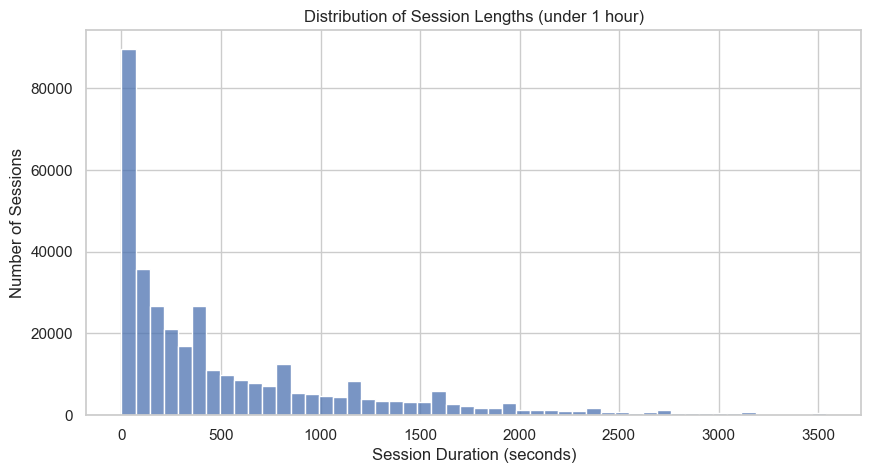

In [15]:
# Extracting time features for product metrics
visits['session_year'] = visits['Start Ts'].dt.year
visits['session_month'] = visits['Start Ts'].dt.month
visits['session_week'] = visits['Start Ts'].dt.isocalendar().week
visits['session_date'] = visits['Start Ts'].dt.date

# 1. Calculating DAU, WAU, and MAU
dau_total = visits.groupby('session_date').agg({'Uid': 'nunique'}).mean()
wau_total = visits.groupby(['session_year', 'session_week']).agg({'Uid': 'nunique'}).mean()
mau_total = visits.groupby(['session_year', 'session_month']).agg({'Uid': 'nunique'}).mean()

print(f"Average Daily Active Users (DAU): {int(dau_total[0])}")
print(f"Average Weekly Active Users (WAU): {int(wau_total[0])}")
print(f"Average Monthly Active Users (MAU): {int(mau_total[0])}")

# 2. Calculating Sessions per User and Average Session Length (ASL)
sessions_per_user = visits.groupby('session_date').agg({'Uid': ['count', 'nunique']})
sessions_per_user.columns = ['n_sessions', 'n_users']
sessions_per_user['sessions_per_user'] = sessions_per_user['n_sessions'] / sessions_per_user['n_users']
print(f"Average sessions per user per day: {sessions_per_user['sessions_per_user'].mean():.2f}")

visits['session_duration_sec'] = (visits['End Ts'] - visits['Start Ts']).dt.seconds
asl = visits['session_duration_sec'].mode()[0]
print(f"Average Session Length (Mode): {asl} seconds")

# Plotting the distribution of session lengths
plt.figure(figsize=(10, 5))
sns.histplot(visits[visits['session_duration_sec'] < 3600]['session_duration_sec'], bins=50, kde=False)
plt.title('Distribution of Session Lengths (under 1 hour)')
plt.xlabel('Session Duration (seconds)')
plt.ylabel('Number of Sessions')
plt.show()

## Step 2.2: Sales Metrics

Here, the focus shifts to purchasing behavior:
1. **Time to Conversion:** How long it takes for a user to make their first purchase.
2. **Purchases per Period:** The frequency of orders.
3. **Average Order Value (AOV):** The average revenue generated per order.

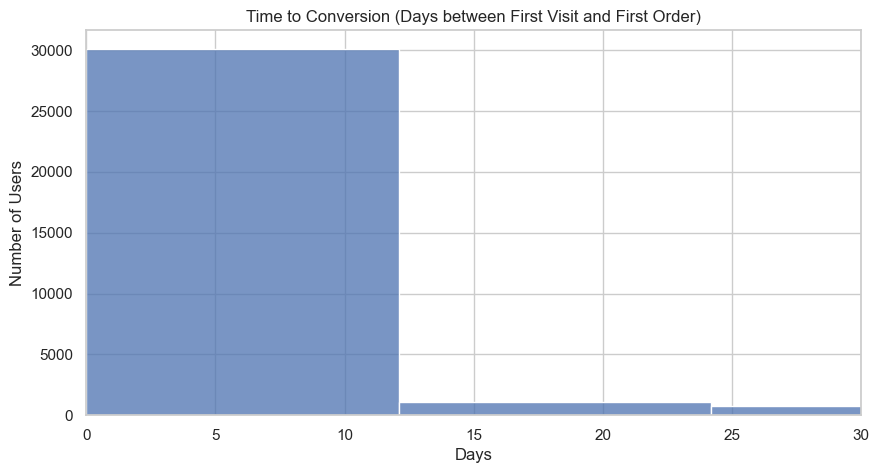

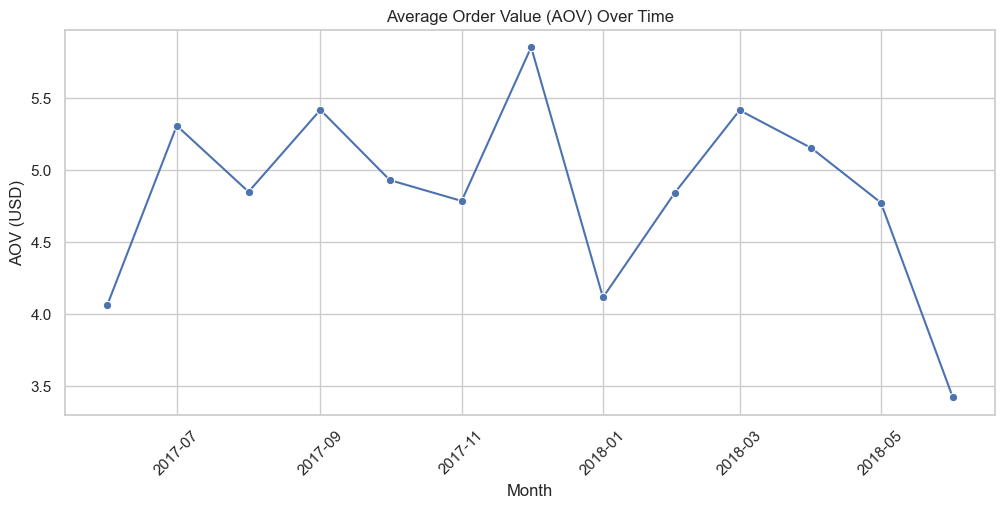

In [16]:
# --- PREPARATION FOR SALES METRICS ---
# Finding the first purchase date for each user
first_orders = orders.groupby('Uid').agg({'Buy Ts': 'min'}).reset_index()
first_orders.columns = ['Uid', 'first_order_date']

# Merging first order date back to the orders dataframe
orders = orders.merge(first_orders, on='Uid')

# Extracting the month for cohort analysis (Updated for Pandas 2.0+)
orders['order_month_str'] = orders['Buy Ts'].dt.to_period('M').dt.to_timestamp()
orders['first_order_month'] = orders['first_order_date'].dt.to_period('M').dt.to_timestamp()

# --- 1. Time to Conversion ---
# Finding the first visit date for each user
first_visits = visits.groupby('Uid').agg({'Start Ts': 'min'}).reset_index()
first_visits.columns = ['Uid', 'first_visit_datetime']

# Merging first visit with first order
conversion_data = first_visits.merge(first_orders, on='Uid', how='inner')

# Calculating the time difference in days
conversion_data['days_to_conversion'] = (conversion_data['first_order_date'] - conversion_data['first_visit_datetime']).dt.days

# Plotting Time to Conversion
plt.figure(figsize=(10, 5))
sns.histplot(conversion_data['days_to_conversion'], bins=30, kde=False)
plt.xlim(0, 30) # Focusing on the first 30 days
plt.title('Time to Conversion (Days between First Visit and First Order)')
plt.xlabel('Days')
plt.ylabel('Number of Users')
plt.show()

# --- 2. Average Order Value (AOV) ---
# Grouping revenue by month
monthly_revenue = orders.groupby('order_month_str').agg({'Revenue': ['sum', 'count']})
monthly_revenue.columns = ['total_revenue', 'n_orders']
monthly_revenue['aov'] = monthly_revenue['total_revenue'] / monthly_revenue['n_orders']

# Plotting AOV over time
plt.figure(figsize=(12, 5))
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue['aov'], marker='o')
plt.title('Average Order Value (AOV) Over Time')
plt.xlabel('Month')
plt.ylabel('AOV (USD)')
plt.xticks(rotation=45)
plt.show()

## Step 2.3: Marketing Metrics

In this section, I will evaluate the financial efficiency of the marketing channels. 
We need to answer three critical questions:
1. **How much money was spent?** (Total and over time).
2. **How much did it cost to acquire a customer?** (CAC).
3. **Did the investments pay off?** (ROMI - Return on Marketing Investment).

By comparing the **Lifetime Value (LTV)** of a cohort with its **CAC**, we can calculate the **ROMI** to see when a cohort breaks even.

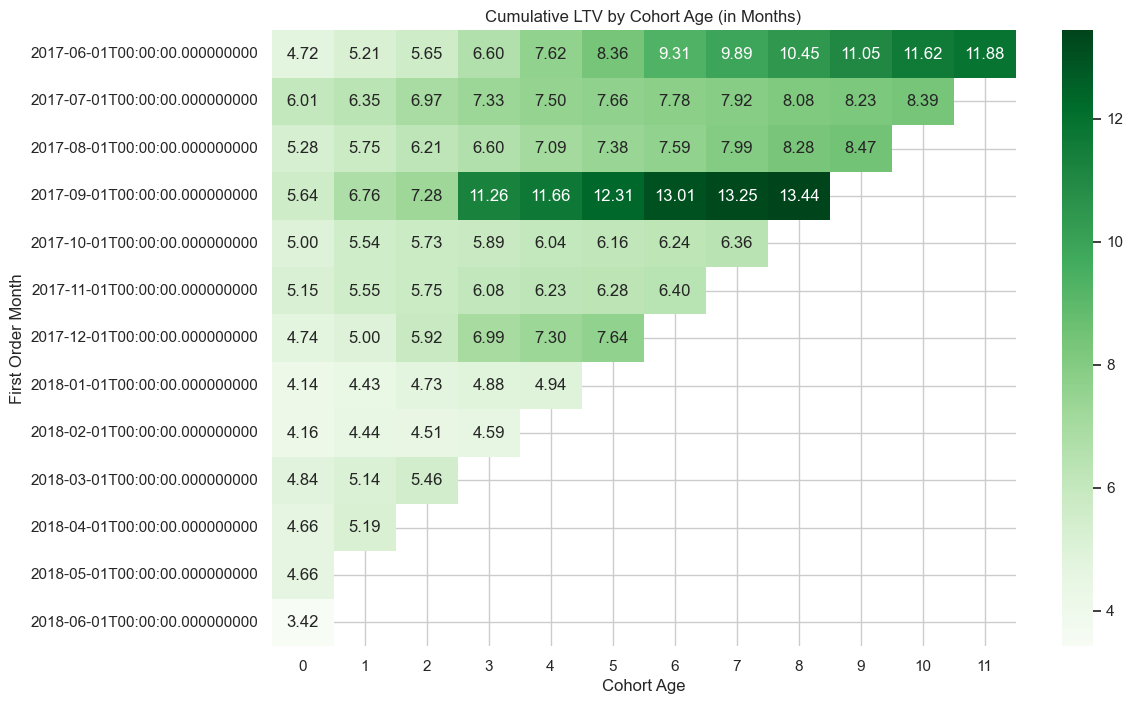

In [17]:
# 1. Calculating LTV (Lifetime Value)
# First, we calculate the number of new buyers per cohort
# (Using the 'orders' dataframe where we saved the 'first_order_month')
cohort_sizes = orders.groupby('first_order_month').agg({'Uid': 'nunique'}).reset_index()
cohort_sizes.columns = ['first_order_month', 'n_buyers']

# Next, we group the revenue by cohort and order month
cohorts = orders.groupby(['first_order_month', 'order_month_str']).agg({'Revenue': 'sum'}).reset_index()

# Merging cohort sizes with their revenues
report = pd.merge(cohort_sizes, cohorts, on='first_order_month')

# Calculating the 'Age' of the cohort in months
report['age'] = (report['order_month_str'].dt.year - report['first_order_month'].dt.year) * 12 + \
                (report['order_month_str'].dt.month - report['first_order_month'].dt.month)

# Calculating LTV (Revenue / Number of buyers)
report['ltv'] = report['Revenue'] / report['n_buyers']

# Creating a pivot table for LTV and calculating the cumulative sum
ltv_pivot = report.pivot_table(index='first_order_month', columns='age', values='ltv', aggfunc='sum')
ltv_cumsum = ltv_pivot.cumsum(axis=1)

# Plotting the Cumulative LTV over time (Cohort Age)
plt.figure(figsize=(12, 8))
sns.heatmap(ltv_cumsum.round(2), annot=True, fmt='.2f', cmap='Greens')
plt.title('Cumulative LTV by Cohort Age (in Months)')
plt.xlabel('Cohort Age')
plt.ylabel('First Order Month')
plt.show()

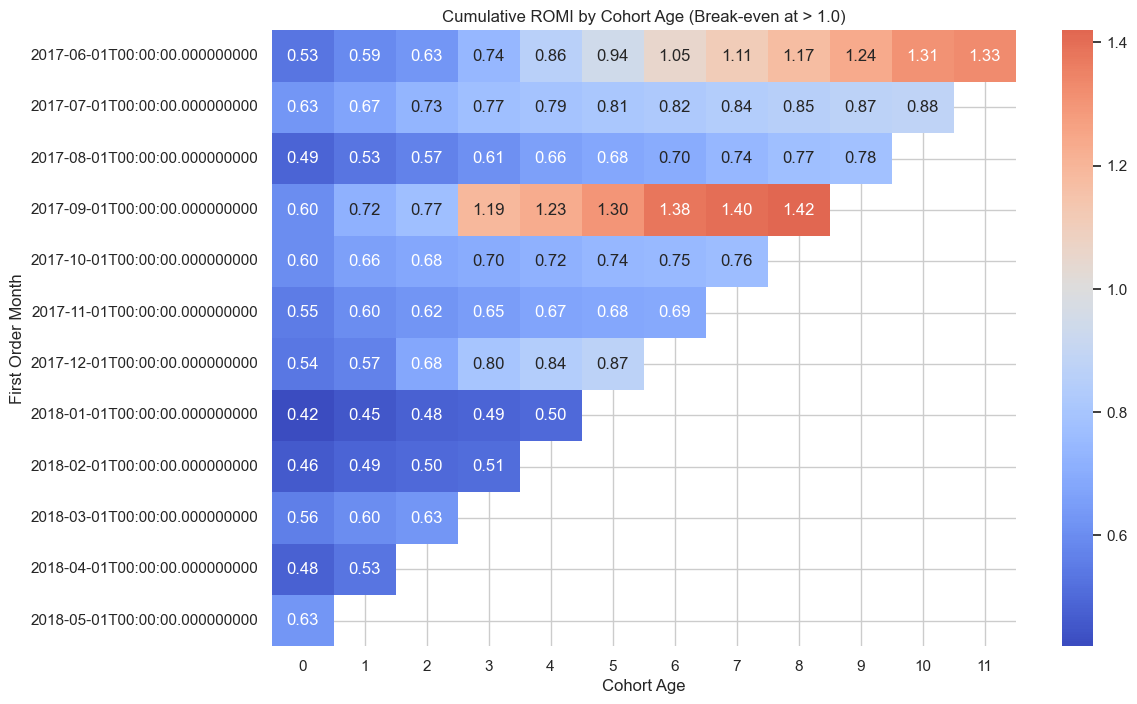

In [18]:
# 2. Calculating CAC and ROMI

# --- PREPARING COSTS DATA ---
# Creating a copy and extracting the month for marketing expenses (Pandas 2.0+ format)
monthly_costs = costs.copy()
monthly_costs['expense_month'] = monthly_costs['dt'].dt.to_period('M').dt.to_timestamp()

# Grouping marketing costs by month
monthly_costs_agg = monthly_costs.groupby('expense_month').agg({'costs': 'sum'}).reset_index()

# --- MERGING AND CALCULATING ---
# Merging the costs with our cohort report
# We match the 'first_order_month' with the 'expense_month'
report_romi = pd.merge(report, monthly_costs_agg, left_on='first_order_month', right_on='expense_month')

# Calculating CAC (Costs / Number of new buyers)
report_romi['cac'] = report_romi['costs'] / report_romi['n_buyers']

# Calculating ROMI (LTV / CAC)
report_romi['romi'] = report_romi['ltv'] / report_romi['cac']

# --- PIVOT TABLE AND HEATMAP ---
# Creating a pivot table for ROMI and calculating the cumulative sum
romi_pivot = report_romi.pivot_table(index='first_order_month', columns='age', values='romi', aggfunc='sum')
romi_cumsum = romi_pivot.cumsum(axis=1).round(2)

# Plotting the Cumulative ROMI
# A ROMI > 1 means the cohort has paid for its marketing acquisition costs (Break-even)
plt.figure(figsize=(12, 8))
sns.heatmap(romi_cumsum, annot=True, fmt='.2f', cmap='coolwarm', center=1.0)
plt.title('Cumulative ROMI by Cohort Age (Break-even at > 1.0)')
plt.xlabel('Cohort Age')
plt.ylabel('First Order Month')
plt.show()

## Step 3: General Conclusion and Business Recommendations

After analyzing the server logs, sales data, and marketing expenses for Y.Afisha from January 2017 to December 2018, I have identified key insights regarding user behavior and marketing efficiency.

### Main Findings:

1. **User Engagement & Conversion:** The Average Session Length is extremely short (the vast majority of sessions end under 100 seconds). Furthermore, the "Time to Conversion" chart clearly shows that almost all buyers convert immediately (within the first few days). If a user doesn't buy right away, they rarely return to buy weeks later.
2. **Break-Even Point & ROMI:** According to the Cumulative ROMI heatmap, many cohorts are struggling to pay for their acquisition costs. However, the **September 2017** cohort is an absolute outlier: it broke even in just 3 months and reached a remarkable ROMI of 1.42. The June 2017 cohort also performed well, breaking even at month 4 (ROMI 1.05).
3. **Average Order Value (AOV):** The AOV fluctuated over time, peaking at around $5.80 in late 2017. Unfortunately, it showed a concerning downward trend in the first half of 2018, dropping to roughly $3.40 by June 2018.

### Recommendations for the Marketing Team:

* **Investigate and Replicate September 2017:** The marketing team must deeply analyze which specific traffic sources and campaigns were active during September 2017. This period brought in highly profitable customers with the highest LTV. We should reallocate our budget to the specific sources that drove this successful cohort.
* **Optimize the "First Impression" Window:** Since session durations are very short and conversions happen almost immediately, our marketing budget should focus heavily on the first interaction. Retargeting campaigns (like push notifications or discounts) should be aggressive within the first 24 to 48 hours. Spending budget trying to convert users who have been inactive for over 15 days is likely a waste of money.
* **Re-evaluate 2018 Marketing Spend:** Recent cohorts (from early 2018) show very low Cumulative ROMI and a dropping AOV. The company is currently losing money on new acquisitions. We must identify the worst-performing traffic sources from these recent months and cut or reduce their funding immediately to stop the financial bleed.

By shifting the focus from simply acquiring *volume* to acquiring *profitable* cohorts (like the September 2017 group), Y.Afisha can significantly optimize its marketing expenses and increase its overall profitability.